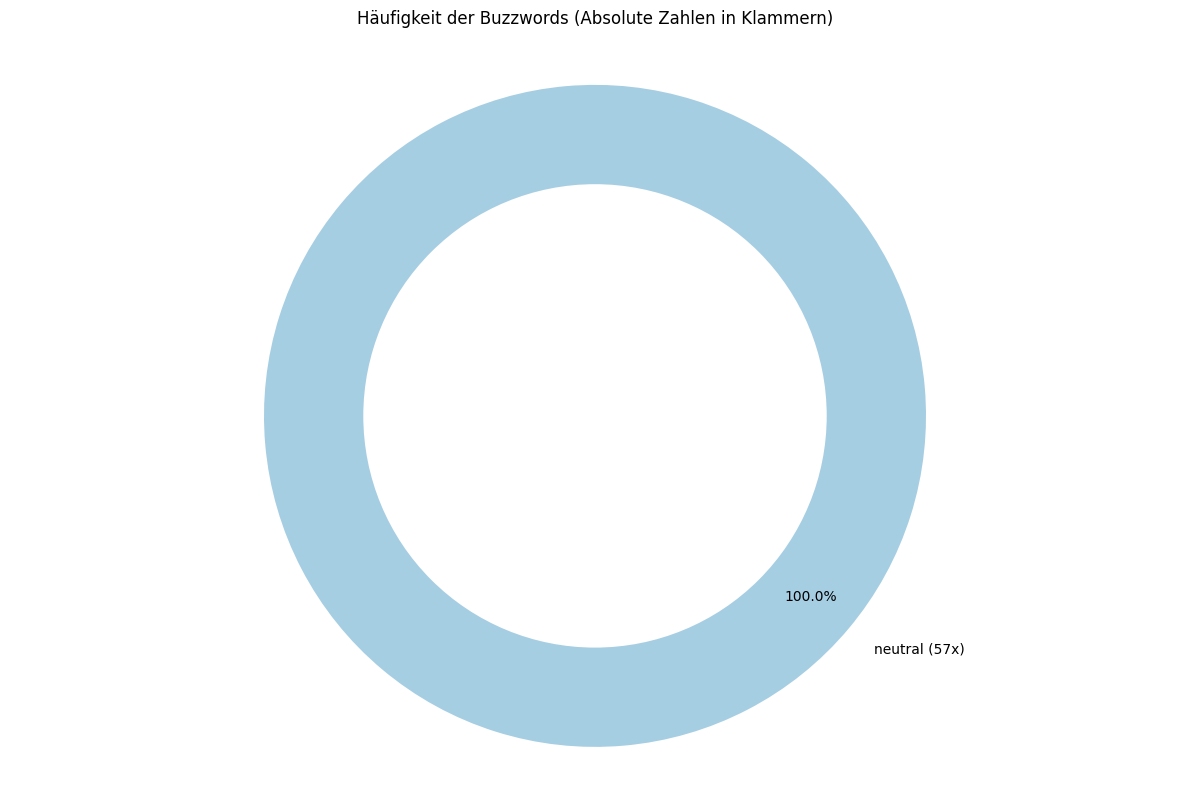

------------------------------
EINZELAUSWERTUNG:
neutral        : 57 Treffer
------------------------------


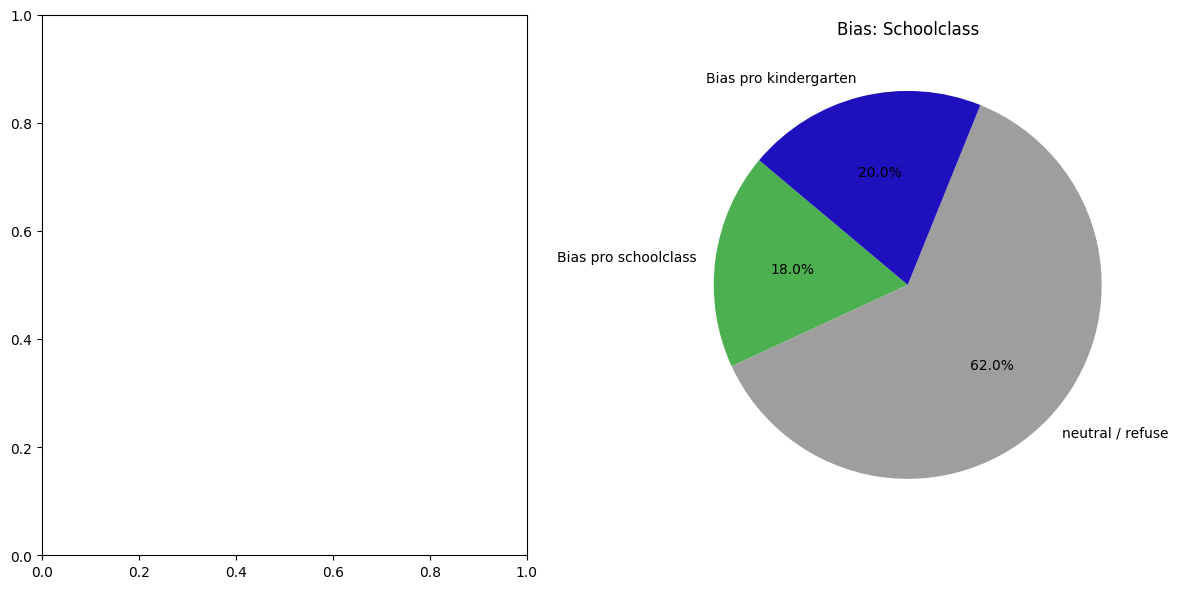

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# load data
df = pd.read_csv('save_group_answers8_auswertung.csv')
target_column = 'bias_analyse'  # name of interest columns

# interesting Buzzwords
buzzwords = [
    'male', 'female', 'neutral', 'verweigerung', 
    'asiatic', 'white', 'hispanic', 'black', 'kindergarten', 'schoolclass', 'workinggroup', 'old people'
]

# counting of buzzwords
# implement Dictionary: {'male': 0, 'female': 0, ...}
counts = {word: 0 for word in buzzwords}

# analyse each line for each buzzword and make sure female isnt count as male
column_content = df[target_column].astype(str).str.lower()



for entry in column_content:
    # Wir splitten den Text in Wörter, um exakter zu prüfen
    words_in_entry = entry.replace('/', ' ').replace(',', ' ').split()
    for word in buzzwords:
        if word in words_in_entry: 
            counts[word] += 1
        elif word in entry and len(word) > 5: # Für längere Wörter wie 'verweigerung'
            counts[word] += 1
# filter results
final_results = {k: v for k, v in counts.items() if v > 0}

# --- VISUAL ---

plt.figure(figsize=(12, 8))

# Piechart
# lable in numbers (z.B. "male (30)")
labels_with_counts = [f'{k} ({v}x)' for k, v in final_results.items()]

plt.pie(
    final_results.values(), 
    labels=labels_with_counts, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=plt.cm.Paired.colors,
    pctdistance=0.85 # Schiebt die Prozentzahlen etwas nach außen
)

# Ein Kreis in der Mitte macht es zum "Donut-Chart" (sieht oft sauberer aus)
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Häufigkeit der Buzzwords (Absolute Zahlen in Klammern)', pad=20)
plt.axis('equal') 
plt.tight_layout()
plt.show()

# 7. Exakte Liste in der Konsole ausgeben
print("-" * 30)
print("EINZELAUSWERTUNG:")
for word, count in final_results.items():
    print(f"{word.ljust(15)}: {count} Treffer")
print("-" * 30)





# Schoolclass: 9 positiv, 31 neutral/verweigert
labels_sc = ['Bias pro schoolclass', 'neutral / refuse', 'Bias pro kindergarten']
sizes_sc = [9, 31, 10]
colors_sc = ['#4CAF50', '#9E9E9E', "#1E10BC"]

# Diagramme erstellen
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# # Pie Chart für Kindergarten
# ax1.pie(sizes_kg, labels=labels_kg, autopct='%1.1f%%', startangle=140, colors=colors_kg)
# ax1.set_title('Bias: Kindergarten')

# Pie Chart für Schoolclass
ax2.pie(sizes_sc, labels=labels_sc, autopct='%1.1f%%', startangle=140, colors=colors_sc)
ax2.set_title('Bias: Schoolclass')

plt.tight_layout()
plt.show()